<div style="font-size: 60px;">
📖 Analysez les ventes d'une librairie
</div>

<div style="font-size: 42px;">
📔 Notebook pour Julie
</div>

# Import des librairies et paramètres généraux

In [1]:
import numpy as np
import scipy
import pandas as pd
import plotly.express as px # renderer="png" requires kaleido (package) + plotly_get_chrome (terminal command)

In [2]:
data_path = "../data/"

# Auxiliaires pour les tests statistiques

In [3]:
def test_normal(df, column, alpha = 0.05):
    print(f'Test de normalité : colonne = "{column}", alpha = {alpha:.3f}')
    print(f"Nombre de valeurs = {df.shape[0]}")
    if df.shape[0] <= 5000:
        test = scipy.stats.shapiro
        test_author = "Shapiro"
    else: # scipy.stats.shapiro() affiche un avertissement "p-value imprécise" lorsque le nombre de valeurs dépasse 5000
        test = scipy.stats.normaltest
        test_author = "D'Agostino et Pearson"
    result = test(df[column])
    print(f"Statistique du test de {test_author} = {result.statistic}")
    print(f"p-value = {result.pvalue:.3f}")
    if result.pvalue > alpha:
        print("Les données suivent une distribution normale.")
    else:
        print("Les données ne suivent pas une distribution normale.")

In [4]:
def test_spearman(df, x, y, alpha = 0.05):
    print(f'Test de Spearman : x = "{x}", y = "{y}", alpha = {alpha:.3f}')
    rho, p = scipy.stats.spearmanr(df[x], df[y])
    print(f"Coefficient de corrélation de Spearman (ρ) = {rho:.3f}")
    print(f"p-value = {p:.3f}")
    if p > alpha:
        print("Le test statistique n'est pas significatif.")
    else:
        print("Le test statistique est significatif.")
    if rho > 0.75:
        print(f'Il existe une corrélation positive forte entre les variables "{x}" et "{y}".')
    elif rho > 0.50:
        print(f'Il existe une corrélation positive modérée entre les variables "{x}" et "{y}".')
    elif rho > 0.25:
        print(f'Il existe une corrélation positive faible entre les variables "{x}" et "{y}".')
    elif rho < -0.75:
        print(f'Il existe une corrélation négative forte entre les variables "{x}" et "{y}".')
    elif rho < -0.50:
        print(f'Il existe une corrélation négative modérée entre les variables "{x}" et "{y}".')
    elif rho < -0.25:
        print(f'Il existe une corrélation négative faible entre les variables "{x}" et "{y}".')
    else:
        print(f'Il n\'y a pas de corrélation entre les variables "{x}" et "{y}".')

In [5]:
def test_kruskal_wallis(df, x, y, alpha = 0.05):
    print(f'Test de Kruskal-Wallis : x = "{x}", y = "{y}", alpha = {alpha:.3f}')
    x_groupby_y = { yvalue: df[x][ (df[y] == yvalue) ] for yvalue in np.sort(df[y].unique()) }
    print()
    for yvalue, xvalues in x_groupby_y.items():
        xvalues.name = f'Valeurs "{x}" lorsque "{y}" = "{yvalue}"'
        print(xvalues.describe())
        print()
    assert len(x_groupby_y) >= 3
    H, p = scipy.stats.kruskal(*x_groupby_y.values())
    print(f"Statistique H du test de Kruskal-Wallis = {H:.3f}")
    print(f"p-value = {p:.3f}")
    if p > alpha:
        print("La différence entre les groupes n'est pas significative.")
    else:
        print("La différence entre les groupes est significative.")
    N = sum(map(len, x_groupby_y.values()))
    eta2 = H / (N-1)
    if eta2 < 0.01:
        print(f"Taille d'effet η² = {eta2:.3f} négligeable")
    elif eta2 < 0.06:
        print(f"Taille d'effet η² = {eta2:.3f} faible")
    elif eta2 < 0.14:
        print(f"Taille d'effet η² = {eta2:.3f} modérée")
    else:
        print(f"Taille d'effet η² = {eta2:.3f} forte")

In [6]:
def test_chi2_contingency(contingency_table, alpha = 0.05, expected_freq = False):
    print(f'Test du χ² entre les variables "{contingency_table.index.name}" et "{contingency_table.columns.name}" avec alpha = {alpha:.3f}')
    result = scipy.stats.chi2_contingency(contingency_table)
    print(f"Statistique χ² = {result.statistic:.3f}")
    print(f"p-value = {result.pvalue:.3f}")
    print(f"Degrés de liberté = {result.dof}")
    if expected_freq:
        df = pd.DataFrame(result.expected_freq, index=contingency_table.index, columns=contingency_table.columns)
        fig = px.imshow(df, text_auto=",d", labels={"y":contingency_table.index.name,"x":contingency_table.columns.name,"color":"Fréquence"}, width=600, height=400)
        fig.update_layout(title=f'Fréquences attendues entre les variables "{contingency_table.index.name}" et "{contingency_table.columns.name}"', title_x=0.5)
        fig.show()
    if result.pvalue > alpha:
        print("L'association entre les deux variables n'est pas significative.")
    else:
        print("L'association entre les deux variables est significative.")
    v_cramer = scipy.stats.contingency.association(contingency_table, method="cramer")
    if v_cramer < 0.1:
        print(f"V de Cramér = {v_cramer:.3f} : association négligeable")
    elif v_cramer < 0.3:
        print(f"V de Cramér = {v_cramer:.3f} : association faible")
    elif v_cramer < 0.5:
        print(f"V de Cramér = {v_cramer:.3f} : association modérée")
    else:
        print(f"V de Cramér = {v_cramer:.3f} : association forte")

# Chargement des données préparées

In [7]:
df_merge = pd.read_csv(data_path + "processed/merge.csv", dtype = "str")
df_merge

,id_prod,price,categ,date,session_id,client_id,sex,birth,age,client_type
0,0_0,3.75,0,2021-03-02 21:57:33.862118,s_908,c_1004,m,1973,49,B2C
1,0_0,3.75,0,2022-02-18 16:40:10.068303,s_167174,c_1011,f,1999,24,B2C
2,0_0,3.75,0,2022-03-18 16:40:10.068303,s_180968,c_1011,f,1999,24,B2C
3,0_0,3.75,0,2022-04-18 16:40:10.068303,s_195932,c_1011,f,1999,24,B2C
4,0_0,3.75,0,2023-02-18 16:40:10.068303,s_343439,c_1011,f,1999,25,B2C
...,...,...,...,...,...,...,...,...,...,...
687529,2_99,84.99,2,2022-07-21 01:53:46.967570,s_241374,c_5828,f,1998,25,B2C
687530,2_99,84.99,2,2023-01-21 01:53:46.967570,s_329932,c_5828,f,1998,26,B2C
687531,2_99,84.99,2,2021-07-11 20:56:49.820935,s_61009,c_7135,m,1996,26,B2C
687532,2_99,84.99,2,2022-11-11 20:56:49.820935,s_296127,c_7135,m,1996,27,B2C


In [8]:
df_merge["price"] = df_merge["price"].astype(float)
df_merge["birth"] = df_merge["birth"].astype(int)
df_merge["age"] = df_merge["age"].astype(int)
df_merge["date"] = pd.to_datetime(df_merge["date"])
df_merge.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 687534 entries, 0 to 687533
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   id_prod      687534 non-null  object        
 1   price        687534 non-null  float64       
 2   categ        687534 non-null  object        
 3   date         687534 non-null  datetime64[ns]
 4   session_id   687534 non-null  object        
 5   client_id    687534 non-null  object        
 6   sex          687534 non-null  object        
 7   birth        687534 non-null  int64         
 8   age          687534 non-null  int64         
 9   client_type  687534 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(6)
memory usage: 52.5+ MB


In [9]:
df_merge_b2c = df_merge[ (df_merge["client_type"] == "B2C") ]
df_merge_b2b = df_merge[ (df_merge["client_type"] == "B2B") ]

# Étude des corrélations

## Lien entre le genre d’un client et les catégories des livres achetés

In [10]:
contingency_table = pd.crosstab(df_merge_b2c["sex"], df_merge_b2c["categ"])
contingency_table

categ,0,1,2
sex,,,
f,200793,115721,16980
m,186488,104884,15868


In [11]:
contingency_table.index = [ "Femmes", "Hommes" ]
contingency_table.index.name = "sex"
contingency_table

categ,0,1,2
sex,,,
Femmes,200793,115721,16980
Hommes,186488,104884,15868


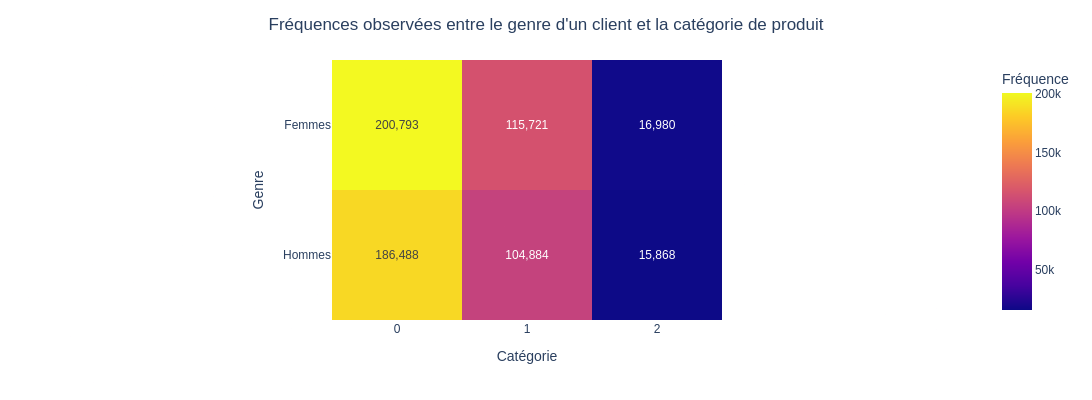

In [12]:
fig = px.imshow(contingency_table, text_auto=",d", labels={"y":"Genre","x":"Catégorie","color":"Fréquence"}, width=600, height=400)
fig.update_layout(title="Fréquences observées entre le genre d'un client et la catégorie de produit", title_x=0.5)
fig.show()

In [13]:
contingency_table_unpivot = contingency_table.reset_index().melt(id_vars="sex", var_name="categ", value_name="frequency")
contingency_table_unpivot

,sex,categ,frequency
0,Femmes,0,200793
1,Hommes,0,186488
2,Femmes,1,115721
3,Hommes,1,104884
4,Femmes,2,16980
5,Hommes,2,15868


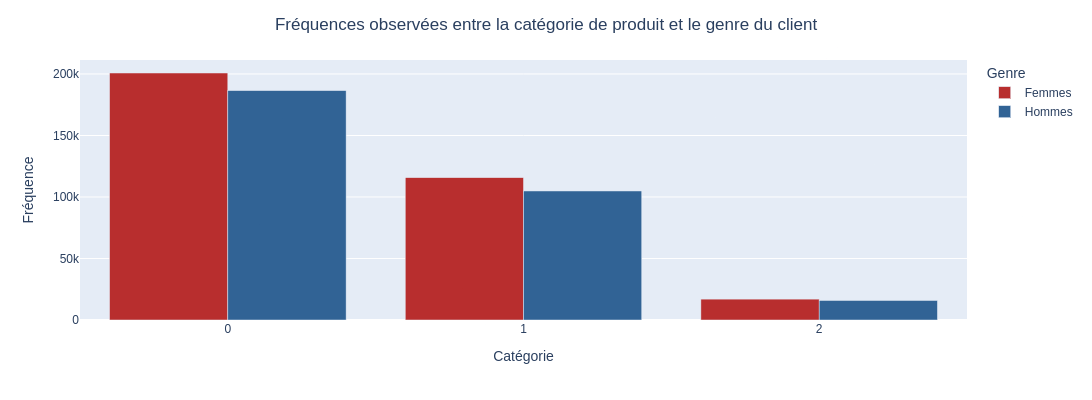

In [14]:
fig = px.bar(
    contingency_table_unpivot, x="categ", y="frequency", color="sex", barmode="group",
    labels={"sex":"Genre","categ":"Catégorie","frequency":"Fréquence"},
    color_discrete_sequence=px.colors.qualitative.G10[-2:], width=600, height=400,
)
fig.update_layout(title="Fréquences observées entre la catégorie de produit et le genre du client", title_x=0.5)
fig.show()

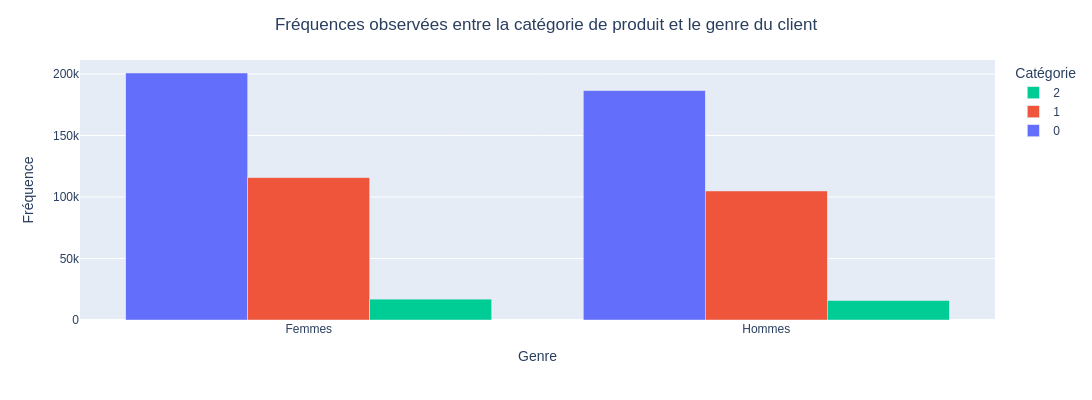

In [15]:
fig = px.bar(
    contingency_table_unpivot, x="sex", y="frequency", color="categ", barmode="group",
    labels={"sex":"Genre","categ":"Catégorie","frequency":"Fréquence"},
    width=600, height=400,
)
fig.update_layout(
    title="Fréquences observées entre la catégorie de produit et le genre du client",
    title_x=0.5,
    legend_traceorder="reversed",
)
fig.show()

Voici ce qu'on observe.

- Les données sont qualitatives.
- Les observations sont indépendantes.
- Les échantillons sont suffisamment grands.
- Le tableau de contingence est de taille 2×3.

Le test adapté est donc le test du χ².

In [16]:
test_chi2_contingency(contingency_table)

Test du χ² entre les variables "sex" et "categ" avec alpha = 0.050
Statistique χ² = 22.669
p-value = 0.000
Degrés de liberté = 2
L'association entre les deux variables est significative.
V de Cramér = 0.006 : association négligeable


## Lien entre l'âge des clients et le montant total des achats

### Agrégation par client

In [110]:
df_customers = df_merge_b2c.groupby("client_id").agg({"age":"mean","price":"sum"}).reset_index()
df_customers.rename(columns={"price":"total_amount_spent"}, inplace=True)
df_customers.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8596 entries, 0 to 8595
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   client_id           8596 non-null   object 
 1   age                 8596 non-null   float64
 2   total_amount_spent  8596 non-null   float64
dtypes: float64(2), object(1)
memory usage: 201.6+ KB


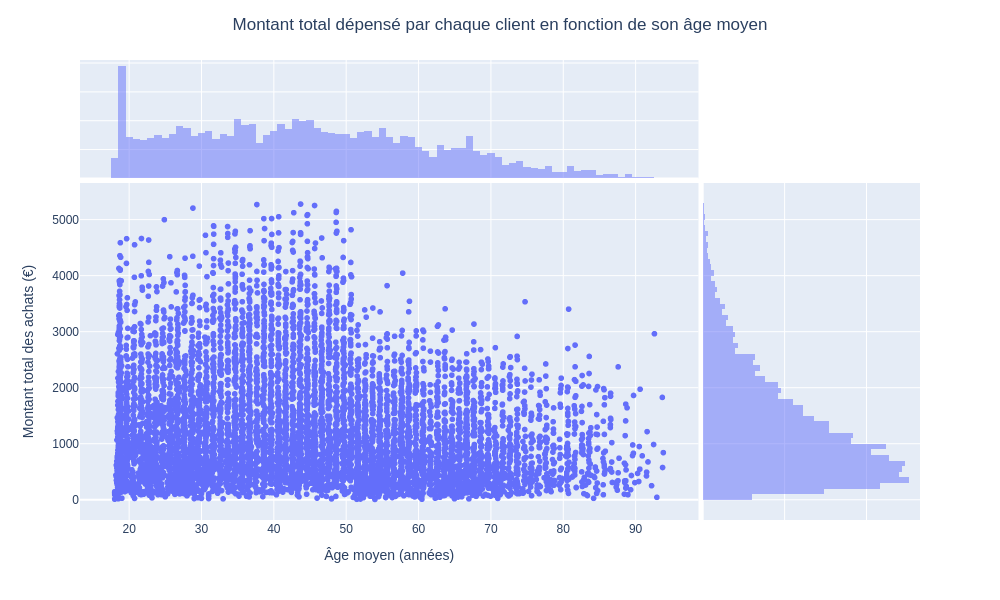

In [111]:
fig = px.scatter(
    df_customers, x="age", y="total_amount_spent",
    labels={"age":"Âge moyen (années)","total_amount_spent":"Montant total des achats (€)"},
    marginal_x="histogram", marginal_y="histogram",
)
fig.update_layout(title="Montant total dépensé par chaque client en fonction de son âge moyen", title_x=0.5, width=1000, height=600)
fig.show(renderer="png")

In [112]:
test_normal(df_customers, "age")

Test de normalité : colonne = "age", alpha = 0.050
Nombre de valeurs = 8596
Statistique du test de D'Agostino et Pearson = 504.6748036943409
p-value = 0.000
Les données ne suivent pas une distribution normale.


In [113]:
test_normal(df_customers, "total_amount_spent")

Test de normalité : colonne = "total_amount_spent", alpha = 0.050
Nombre de valeurs = 8596
Statistique du test de D'Agostino et Pearson = 1455.2479901545262
p-value = 0.000
Les données ne suivent pas une distribution normale.


Aucune des deux variables quantitatives ne suit une distribution normale : le test adapté est donc celui de Spearman.

In [114]:
test_spearman(df_customers, "age", "total_amount_spent")

Test de Spearman : x = "age", y = "total_amount_spent", alpha = 0.050
Coefficient de corrélation de Spearman (ρ) = -0.180
p-value = 0.000
Le test statistique est significatif.
Il n'y a pas de corrélation entre les variables "age" et "total_amount_spent".


### Agrégation par âge

In [115]:
df_age = df_merge_b2c.groupby("session_id").agg({"age":"min","price":"sum"}).reset_index()
df_age = df_age.groupby("age").agg({"price":"sum"}).reset_index()
df_age.rename(columns={"price":"total_amount_spent"}, inplace=True)
df_age.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78 entries, 0 to 77
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   age                 78 non-null     int64  
 1   total_amount_spent  78 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 1.3 KB


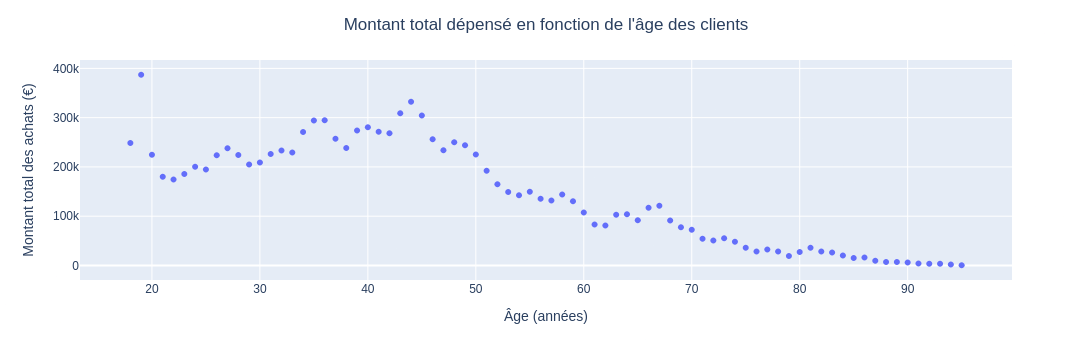

In [116]:
fig = px.scatter(
    df_age, x="age", y="total_amount_spent",
    labels={"age":"Âge (années)","total_amount_spent":"Montant total des achats (€)"},
)
fig.update_layout(title="Montant total dépensé en fonction de l'âge des clients", title_x=0.5)
fig.show()

In [117]:
test_normal(df_age, "age")

Test de normalité : colonne = "age", alpha = 0.050
Nombre de valeurs = 78
Statistique du test de Shapiro = 0.9548981526896895
p-value = 0.008
Les données ne suivent pas une distribution normale.


In [118]:
test_normal(df_age, "total_amount_spent")

Test de normalité : colonne = "total_amount_spent", alpha = 0.050
Nombre de valeurs = 78
Statistique du test de Shapiro = 0.932273412683106
p-value = 0.000
Les données ne suivent pas une distribution normale.


Aucune des deux variables quantitatives ne suit une distribution normale : le test adapté est donc celui de Spearman.

In [119]:
test_spearman(df_age, "age", "total_amount_spent")

Test de Spearman : x = "age", y = "total_amount_spent", alpha = 0.050
Coefficient de corrélation de Spearman (ρ) = -0.880
p-value = 0.000
Le test statistique est significatif.
Il existe une corrélation négative forte entre les variables "age" et "total_amount_spent".


### Partition en tranches d'âge et régression linéaire

In [120]:
df_customers["age_group"] = df_customers["age"].map(lambda age: "18-31 ans" if age < 32 else "32-51 ans" if age < 52 else "52+ ans")
df_customers["age_group"].describe()

count          8596
unique            3
top       32-51 ans
freq           3381
Name: age_group, dtype: object

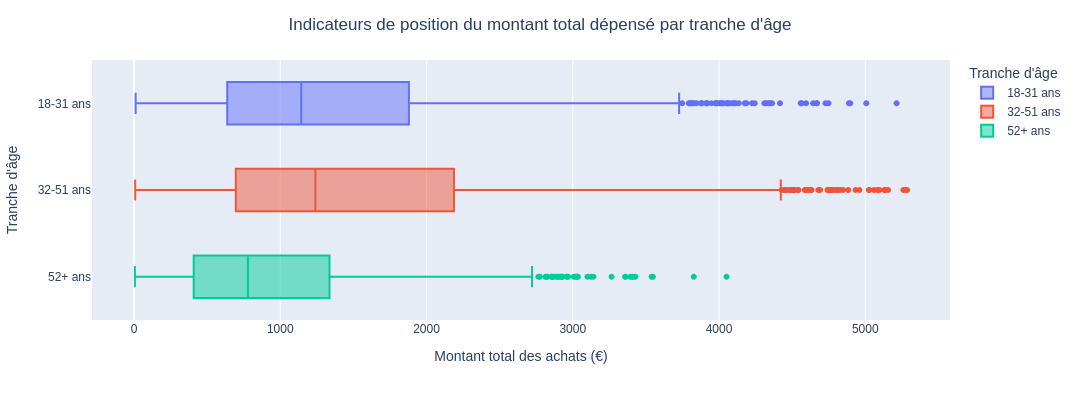

In [121]:
fig = px.box(
    df_customers, y="age_group", x="total_amount_spent", color="age_group",
    labels={"age_group":"Tranche d'âge","total_amount_spent":"Montant total des achats (€)"},
    category_orders={"age_group":["18-31 ans","32-51 ans","52+ ans"]},
)
fig.update_layout(title="Indicateurs de position du montant total dépensé par tranche d'âge", title_x=0.5, width=1000, height=400)
fig.show()

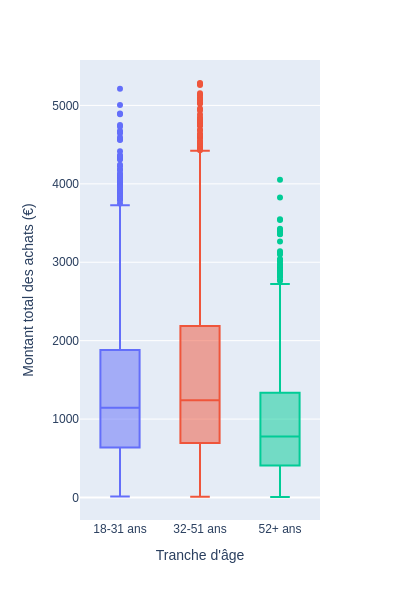

In [122]:
fig = px.box(
    df_customers, x="age_group", y="total_amount_spent", color="age_group",
    labels={"age_group":"Tranche d'âge","total_amount_spent":"Montant total des achats (€)"},
    category_orders={"age_group":["18-31 ans","32-51 ans","52+ ans"]},
)
fig.update_layout(showlegend=False, width=400, height=600)
fig.show(renderer="png")

In [29]:
test_normal(df_customers, "total_amount_spent")

Test de normalité : colonne = "total_amount_spent", alpha = 0.050
Nombre de valeurs = 8596
Statistique du test de D'Agostino et Pearson = 1455.2479901545262
p-value = 0.000
Les données ne suivent pas une distribution normale.


D'une part, la variable qualitative "tranche d'âge" a 3 modes/groupes.  
D'autre part, la variable quantitative "montant total dépensé" ne suit pas une distribution normale.  
Le test adapté est donc le test Kruskal-Wallis.

In [30]:
test_kruskal_wallis(df_customers, "total_amount_spent", "age_group")

Test de Kruskal-Wallis : x = "total_amount_spent", y = "age_group", alpha = 0.050

count    2410.000000
mean     1357.722743
std       943.524813
min        11.200000
25%       637.782500
50%      1143.405000
75%      1879.552500
max      5214.050000
Name: Valeurs "total_amount_spent" lorsque "age_group" = "18-31 ans", dtype: float64

count    3381.000000
mean     1543.347314
std      1075.697399
min         8.300000
25%       696.180000
50%      1240.150000
75%      2185.420000
max      5285.820000
Name: Valeurs "total_amount_spent" lorsque "age_group" = "32-51 ans", dtype: float64

count    2805.000000
mean      945.881615
std       675.456120
min         6.310000
25%       408.420000
50%       779.020000
75%      1336.640000
max      4051.430000
Name: Valeurs "total_amount_spent" lorsque "age_group" = "52+ ans", dtype: float64

Statistique H du test de Kruskal-Wallis = 559.568
p-value = 0.000
La différence entre les groupes est significative.
Taille d'effet η² = 0.065 modérée


In [31]:
df_age["age_group"] = df_age["age"].map(lambda age: "18-31 ans" if age < 32 else "32-51 ans" if age < 52 else "52+ ans")
df_age["age_group"].describe()

count          78
unique          3
top       52+ ans
freq           44
Name: age_group, dtype: object

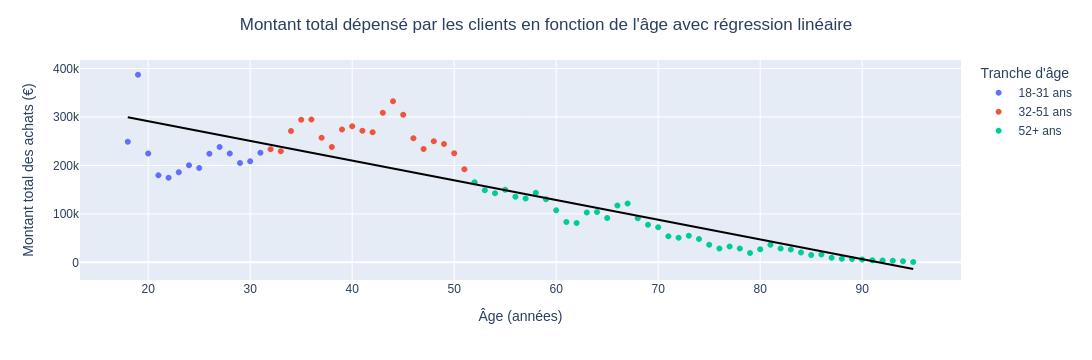

In [32]:
fig = px.scatter(
    df_age, x="age", y="total_amount_spent", color="age_group",
    labels={"age":"Âge (années)","total_amount_spent":"Montant total des achats (€)","age_group":"Tranche d'âge"},
    trendline="ols", trendline_scope="overall", trendline_color_override="black",
)
fig.update_traces(showlegend=False, selector={"name":"Overall Trendline"})
fig.update_layout(title="Montant total dépensé par les clients en fonction de l'âge avec régression linéaire", title_x=0.5)
fig.show()

## Lien entre l'âge des clients et la fréquence d’achat

### Agrégation par client

In [97]:
df_customers = df_merge_b2c.groupby("client_id").agg({"age":"mean","session_id":"nunique"}).reset_index()
df_customers.rename(columns={"session_id":"session_count"}, inplace=True)
df_customers.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8596 entries, 0 to 8595
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   client_id      8596 non-null   object 
 1   age            8596 non-null   float64
 2   session_count  8596 non-null   int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 201.6+ KB


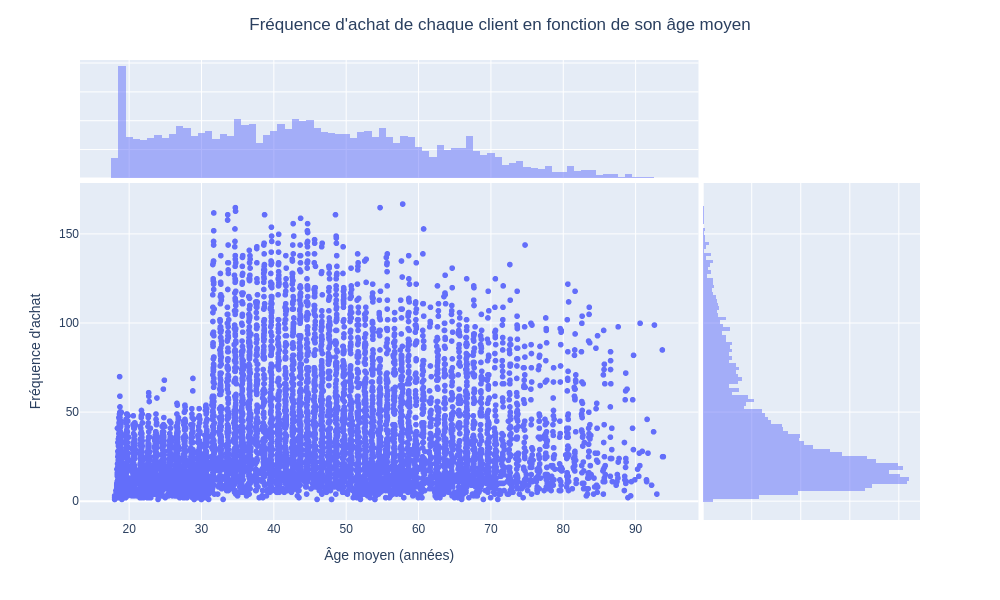

In [98]:
fig = px.scatter(
    df_customers, x="age", y="session_count", labels={"age":"Âge moyen (années)","session_count":"Fréquence d'achat"},
    marginal_x="histogram", marginal_y="histogram",
)
fig.update_layout(title="Fréquence d'achat de chaque client en fonction de son âge moyen", title_x=0.5, width=1000, height=600)
fig.show(renderer="png")

In [99]:
test_normal(df_customers, "age")

Test de normalité : colonne = "age", alpha = 0.050
Nombre de valeurs = 8596
Statistique du test de D'Agostino et Pearson = 504.6748036943409
p-value = 0.000
Les données ne suivent pas une distribution normale.


In [100]:
test_normal(df_customers, "session_count")

Test de normalité : colonne = "session_count", alpha = 0.050
Nombre de valeurs = 8596
Statistique du test de D'Agostino et Pearson = 1815.6962594779288
p-value = 0.000
Les données ne suivent pas une distribution normale.


Aucune des deux variables quantitatives ne suit une distribution normale : le test adapté est donc celui de Spearman.

In [101]:
test_spearman(df_customers, "age", "session_count")

Test de Spearman : x = "age", y = "session_count", alpha = 0.050
Coefficient de corrélation de Spearman (ρ) = 0.215
p-value = 0.000
Le test statistique est significatif.
Il n'y a pas de corrélation entre les variables "age" et "session_count".


### Agrégation par âge

In [102]:
df_age = df_merge_b2c.groupby(["session_id","client_id"]).agg({"age":"min"}).reset_index()
df_age = df_age.groupby("age").agg({"session_id":"nunique","client_id":"nunique"}).reset_index()
df_age.rename(columns={"session_id":"session_nunique","client_id":"client_nunique"}, inplace=True)
df_age["session_count"] = df_age["session_nunique"] / df_age["client_nunique"]
df_age.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78 entries, 0 to 77
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              78 non-null     int64  
 1   session_nunique  78 non-null     int64  
 2   client_nunique   78 non-null     int64  
 3   session_count    78 non-null     float64
dtypes: float64(1), int64(3)
memory usage: 2.6 KB


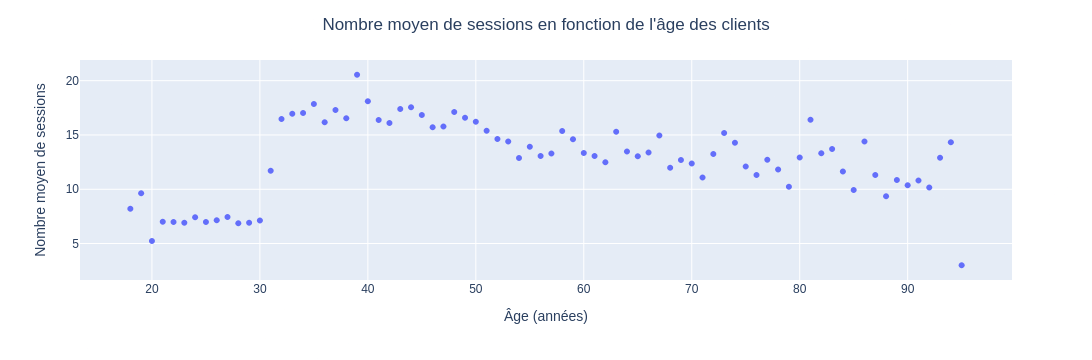

In [103]:
fig = px.scatter(
    df_age, x="age", y="session_count",
    labels={"age":"Âge (années)","session_count":"Nombre moyen de sessions"},
)
fig.update_layout(title="Nombre moyen de sessions en fonction de l'âge des clients", title_x=0.5)
fig.show()

In [104]:
test_normal(df_age, "age")

Test de normalité : colonne = "age", alpha = 0.050
Nombre de valeurs = 78
Statistique du test de Shapiro = 0.9548981526896895
p-value = 0.008
Les données ne suivent pas une distribution normale.


In [105]:
test_normal(df_age, "session_count")

Test de normalité : colonne = "session_count", alpha = 0.050
Nombre de valeurs = 78
Statistique du test de Shapiro = 0.9642396283170132
p-value = 0.027
Les données ne suivent pas une distribution normale.


Aucune des deux variables quantitatives ne suit une distribution normale : le test adapté est donc celui de Spearman.

In [106]:
test_spearman(df_age, "age", "session_count")

Test de Spearman : x = "age", y = "session_count", alpha = 0.050
Coefficient de corrélation de Spearman (ρ) = -0.049
p-value = 0.671
Le test statistique n'est pas significatif.
Il n'y a pas de corrélation entre les variables "age" et "session_count".


### Partition en tranches d'âge

In [107]:
df_customers["age_group"] = df_customers["age"].map(lambda age: "18-31 ans" if age < 32 else "32-51 ans" if age < 52 else "52+ ans")
df_customers["age_group"].describe()

count          8596
unique            3
top       32-51 ans
freq           3381
Name: age_group, dtype: object

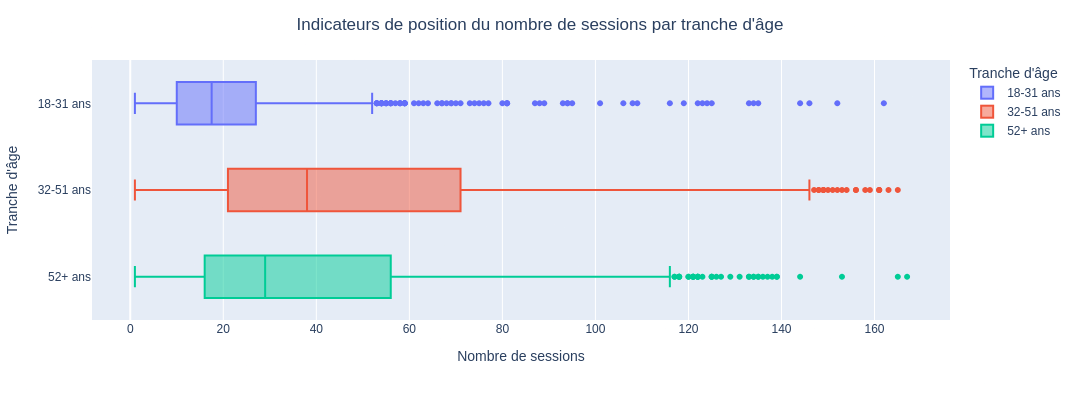

In [108]:
fig = px.box(
    df_customers, y="age_group", x="session_count", color="age_group",
    labels={"age_group":"Tranche d'âge","session_count":"Nombre de sessions"},
    category_orders={"age_group":["18-31 ans","32-51 ans","52+ ans"]},
)
fig.update_layout(title="Indicateurs de position du nombre de sessions par tranche d'âge", title_x=0.5, width=1000, height=400)
fig.show()

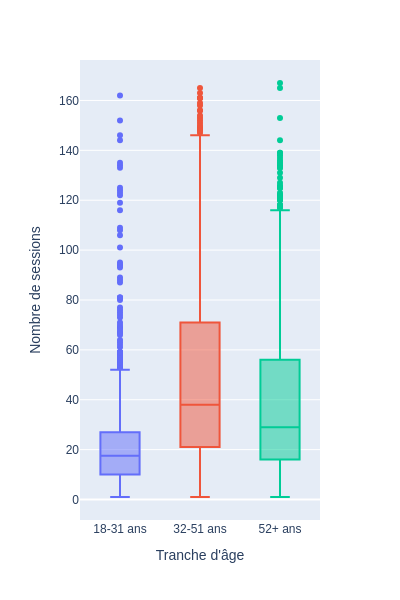

In [109]:
fig = px.box(
    df_customers, x="age_group", y="session_count", color="age_group",
    labels={"age_group":"Tranche d'âge","session_count":"Nombre de sessions"},
    category_orders={"age_group":["18-31 ans","32-51 ans","52+ ans"]},
)
fig.update_layout(showlegend=False, width=400, height=600)
fig.show(renderer="png")

In [45]:
test_normal(df_customers, "session_count")

Test de normalité : colonne = "session_count", alpha = 0.050
Nombre de valeurs = 8596
Statistique du test de D'Agostino et Pearson = 1815.6962594779288
p-value = 0.000
Les données ne suivent pas une distribution normale.


D'une part, la variable qualitative "tranche d'âge" a 3 modes/groupes.  
D'autre part, la variable quantitative "nombre moyen de sessions" ne suit pas une distribution normale.  
Le test adapté est donc le test Kruskal-Wallis.

In [46]:
test_kruskal_wallis(df_customers, "session_count", "age_group")

Test de Kruskal-Wallis : x = "session_count", y = "age_group", alpha = 0.050

count    2410.000000
mean       20.880913
std        16.117136
min         1.000000
25%        10.000000
50%        17.500000
75%        27.000000
max       162.000000
Name: Valeurs "session_count" lorsque "age_group" = "18-31 ans", dtype: float64

count    3381.0000
mean       48.5874
std        34.7375
min         1.0000
25%        21.0000
50%        38.0000
75%        71.0000
max       165.0000
Name: Valeurs "session_count" lorsque "age_group" = "32-51 ans", dtype: float64

count    2805.000000
mean       38.455971
std        29.364123
min         1.000000
25%        16.000000
50%        29.000000
75%        56.000000
max       167.000000
Name: Valeurs "session_count" lorsque "age_group" = "52+ ans", dtype: float64

Statistique H du test de Kruskal-Wallis = 1269.406
p-value = 0.000
La différence entre les groupes est significative.
Taille d'effet η² = 0.148 forte


In [47]:
df_age["age_group"] = df_age["age"].map(lambda age: "18-31 ans" if age < 32 else "32-51 ans" if age < 52 else "52+ ans")
df_age["age_group"].describe()

count          78
unique          3
top       52+ ans
freq           44
Name: age_group, dtype: object

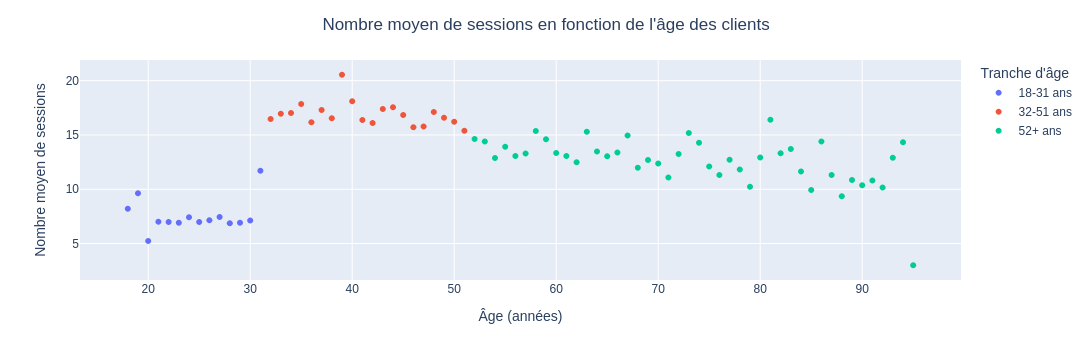

In [48]:
fig = px.scatter(
    df_age, x="age", y="session_count", color="age_group",
    labels={"age":"Âge (années)","session_count":"Nombre moyen de sessions","age_group":"Tranche d'âge"},
    # trendline="ols", trendline_scope="trace",
)
fig.update_layout(
    title="Nombre moyen de sessions en fonction de l'âge des clients",
    # title="Nombre moyen de sessions en fonction de l'âge des clients avec régression linéaire par tranche d'âge",
    title_x=0.5,
)
fig.show()

## Lien entre l'âge des clients et la taille du panier moyen

### Agrégation par client

In [76]:
# Calcul de la taille de chaque panier
df_customers = df_merge_b2c.groupby(["client_id","session_id"]).agg({"age":"mean","id_prod":"count"}).reset_index()
df_customers.rename(columns={"id_prod":"session_size"}, inplace=True)
# Calcul de la taille du panier moyen
df_customers = df_customers.groupby("client_id").agg({"age":"mean","session_size":"mean"}).reset_index()
df_customers.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8596 entries, 0 to 8595
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   client_id     8596 non-null   object 
 1   age           8596 non-null   float64
 2   session_size  8596 non-null   float64
dtypes: float64(2), object(1)
memory usage: 201.6+ KB


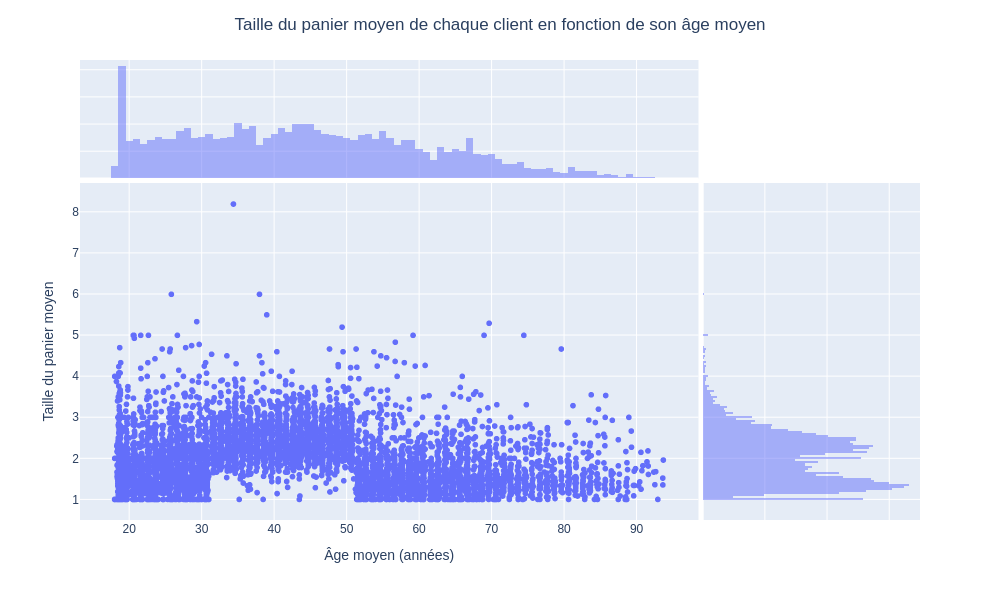

In [77]:
fig = px.scatter(
    df_customers, x="age", y="session_size", labels={"age":"Âge moyen (années)","session_size":"Taille du panier moyen"},
    marginal_x="histogram", marginal_y="histogram",
)
fig.update_layout(title="Taille du panier moyen de chaque client en fonction de son âge moyen", title_x=0.5, width=1000, height=600)
fig.show(renderer="png")

In [78]:
test_normal(df_customers, "age")

Test de normalité : colonne = "age", alpha = 0.050
Nombre de valeurs = 8596
Statistique du test de D'Agostino et Pearson = 504.41338767532943
p-value = 0.000
Les données ne suivent pas une distribution normale.


In [79]:
test_normal(df_customers, "session_size")

Test de normalité : colonne = "session_size", alpha = 0.050
Nombre de valeurs = 8596
Statistique du test de D'Agostino et Pearson = 1223.8028999150376
p-value = 0.000
Les données ne suivent pas une distribution normale.


Aucune des deux variables quantitatives ne suit une distribution normale : le test adapté est donc celui de Spearman.

In [80]:
test_spearman(df_customers, "age", "session_size")

Test de Spearman : x = "age", y = "session_size", alpha = 0.050
Coefficient de corrélation de Spearman (ρ) = -0.208
p-value = 0.000
Le test statistique est significatif.
Il n'y a pas de corrélation entre les variables "age" et "session_size".


### Agrégation par âge

In [81]:
df_age = df_merge_b2c.groupby("session_id").agg({"age":"min","id_prod":"count"}).reset_index()
df_age = df_age.groupby("age").agg({"id_prod":"mean"}).reset_index()
df_age.rename(columns={"id_prod":"session_size"}, inplace=True)
df_age.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78 entries, 0 to 77
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           78 non-null     int64  
 1   session_size  78 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 1.3 KB


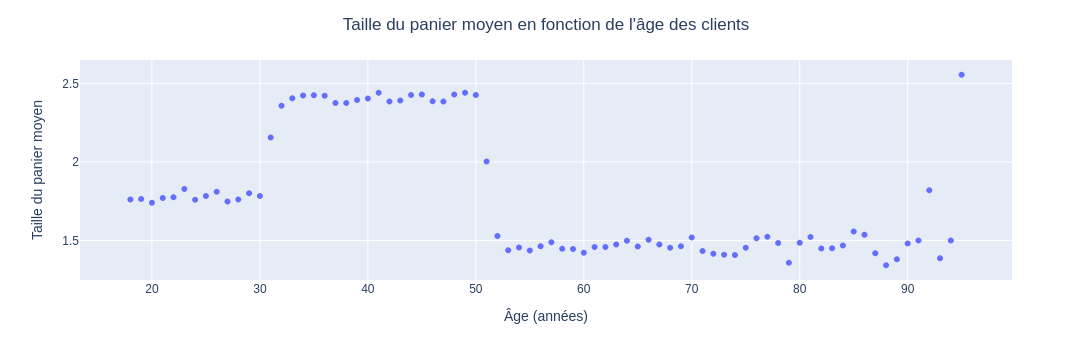

In [82]:
fig = px.scatter(
    df_age, x="age", y="session_size",
    labels={"age":"Âge (années)","session_size":"Taille du panier moyen"},
)
fig.update_layout(title="Taille du panier moyen en fonction de l'âge des clients", title_x=0.5)
fig.show()

In [83]:
test_normal(df_age, "age")

Test de normalité : colonne = "age", alpha = 0.050
Nombre de valeurs = 78
Statistique du test de Shapiro = 0.9548981526896895
p-value = 0.008
Les données ne suivent pas une distribution normale.


In [84]:
test_normal(df_age, "session_size")

Test de normalité : colonne = "session_size", alpha = 0.050
Nombre de valeurs = 78
Statistique du test de Shapiro = 0.7832266738713685
p-value = 0.000
Les données ne suivent pas une distribution normale.


Aucune des deux variables quantitatives ne suit une distribution normale : le test adapté est donc celui de Spearman.

In [85]:
test_spearman(df_age, "age", "session_size")

Test de Spearman : x = "age", y = "session_size", alpha = 0.050
Coefficient de corrélation de Spearman (ρ) = -0.575
p-value = 0.000
Le test statistique est significatif.
Il existe une corrélation négative modérée entre les variables "age" et "session_size".


### Partition en tranches d'âge

In [86]:
df_customers["age_group"] = df_customers["age"].map(lambda age: "18-31 ans" if age < 32 else "32-51 ans" if age < 52 else "52+ ans")
df_customers["age_group"].describe()

count          8596
unique            3
top       32-51 ans
freq           3381
Name: age_group, dtype: object

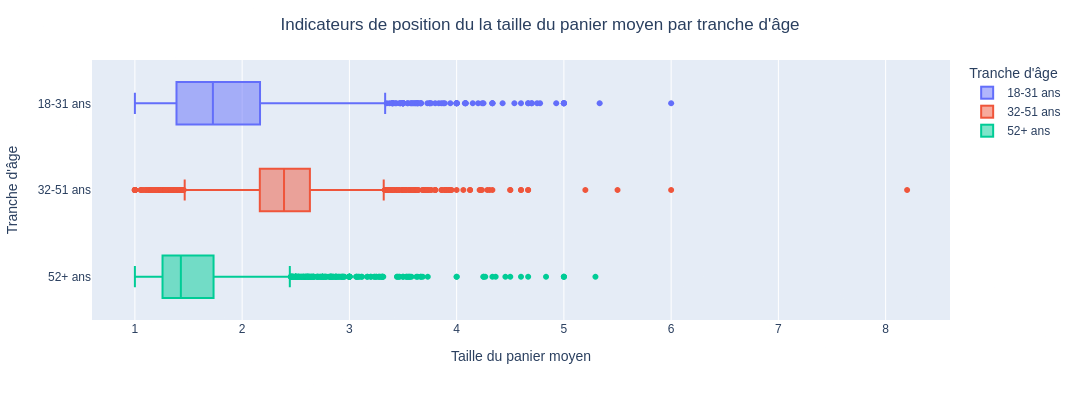

In [87]:
fig = px.box(
    df_customers, y="age_group", x="session_size", color="age_group",
    labels={"age_group":"Tranche d'âge","session_size":"Taille du panier moyen"},
    category_orders={"age_group":["18-31 ans","32-51 ans","52+ ans"]},
)
fig.update_layout(title="Indicateurs de position du la taille du panier moyen par tranche d'âge", title_x=0.5, width=1000, height=400)
fig.show()

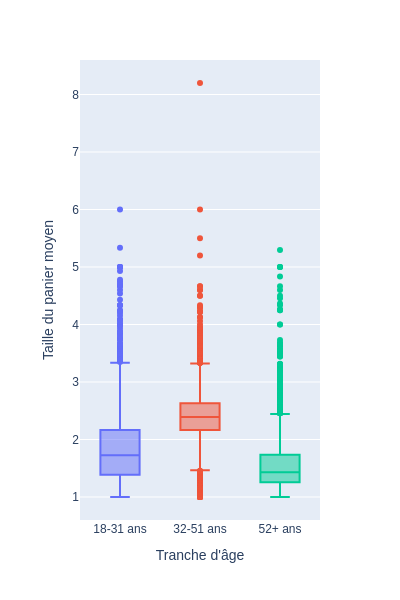

In [96]:
fig = px.box(
    df_customers, x="age_group", y="session_size", color="age_group",
    labels={"age_group":"Tranche d'âge","session_size":"Taille du panier moyen"},
    category_orders={"age_group":["18-31 ans","32-51 ans","52+ ans"]},
)
fig.update_layout(showlegend=False, width=400, height=600)
fig.show(renderer="png")

In [61]:
test_normal(df_customers, "session_size")

Test de normalité : colonne = "session_size", alpha = 0.050
Nombre de valeurs = 8596
Statistique du test de D'Agostino et Pearson = 1223.8028999150376
p-value = 0.000
Les données ne suivent pas une distribution normale.


D'une part, la variable qualitative "tranche d'âge" a 3 modes/groupes.  
D'autre part, la variable quantitative "taille du panier moyen" ne suit pas une distribution normale.  
Le test adapté est donc celui de Kruskal-Wallis.

In [62]:
test_kruskal_wallis(df_customers, "session_size", "age_group")

Test de Kruskal-Wallis : x = "session_size", y = "age_group", alpha = 0.050

count    2410.000000
mean        1.857098
std         0.652818
min         1.000000
25%         1.388039
50%         1.727273
75%         2.166667
max         6.000000
Name: Valeurs "session_size" lorsque "age_group" = "18-31 ans", dtype: float64

count    3381.000000
mean        2.408982
std         0.478174
min         1.000000
25%         2.164706
50%         2.390411
75%         2.631579
max         8.200000
Name: Valeurs "session_size" lorsque "age_group" = "32-51 ans", dtype: float64

count    2805.000000
mean        1.581101
std         0.512305
min         1.000000
25%         1.257576
50%         1.428571
75%         1.733333
max         5.294118
Name: Valeurs "session_size" lorsque "age_group" = "52+ ans", dtype: float64

Statistique H du test de Kruskal-Wallis = 3210.745
p-value = 0.000
La différence entre les groupes est significative.
Taille d'effet η² = 0.374 forte


In [63]:
df_age["age_group"] = df_age["age"].map(lambda age: "18-31 ans" if age < 32 else "32-51 ans" if age < 52 else "52+ ans")
df_age["age_group"].describe()

count          78
unique          3
top       52+ ans
freq           44
Name: age_group, dtype: object

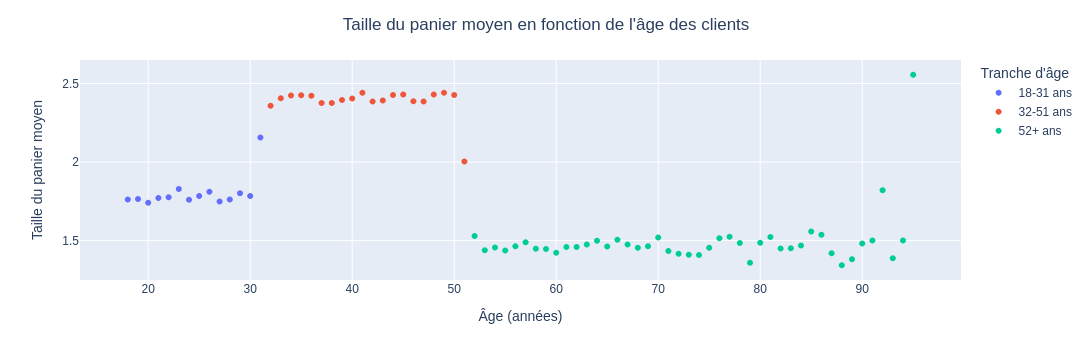

In [64]:
fig = px.scatter(
    df_age, x="age", y="session_size", color="age_group",
    labels={"age":"Âge (années)","age_group":"Tranche d'âge","session_size":"Taille du panier moyen"},
    category_orders={"age_group":["18-31 ans","32-51 ans","52+ ans"]},
    # trendline="ols", trendline_scope="trace",
)
fig.update_layout(
    title="Taille du panier moyen en fonction de l'âge des clients",
    # title="Taille du panier moyen en fonction de l'âge des clients avec régression linéaire par tranche d'âge",
    title_x=0.5,
)
fig.show()

## Lien entre l'âge des clients et la catégorie des livres achetés

### Vue globale sur l'ensemble des transactions

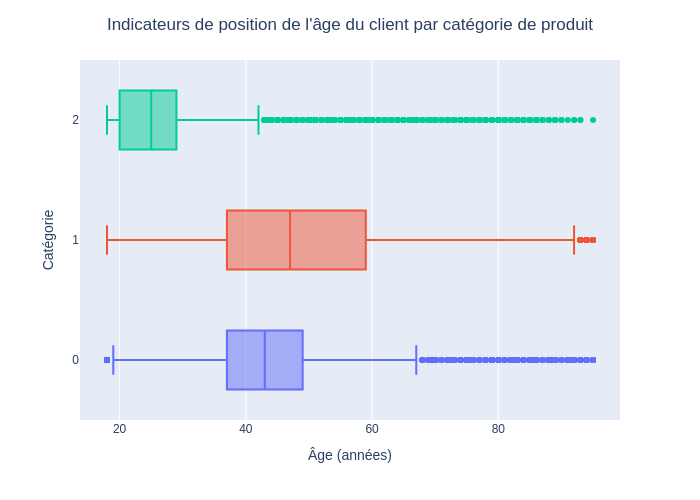

In [65]:
fig = px.box(
    df_merge_b2c, x="age", y="categ", color="categ",
    labels={"age":"Âge (années)","categ":"Catégorie"},
    category_orders={"categ":["0","1","2"]},
)
fig.update_layout(title="Indicateurs de position de l'âge du client par catégorie de produit", title_x=0.5)
fig.update_layout(yaxis_categoryorder="category ascending", showlegend=False)
fig.show(renderer="png")

In [66]:
test_normal(df_merge_b2c, "age")

Test de normalité : colonne = "age", alpha = 0.050
Nombre de valeurs = 640734
Statistique du test de D'Agostino et Pearson = 33722.748747878046
p-value = 0.000
Les données ne suivent pas une distribution normale.


D'une part, la variable qualitative "catégorie" a 3 modes/groupes.  
D'autre part, la variable quantitative "âge" ne suit pas une distribution normale.  
Le test adapté est donc celui de Kruskal-Wallis.

In [67]:
test_kruskal_wallis(df_merge_b2c, "age", "categ")

Test de Kruskal-Wallis : x = "age", y = "categ", alpha = 0.050

count    387281.000000
mean         44.446784
std          11.531819
min          18.000000
25%          37.000000
50%          43.000000
75%          49.000000
max          95.000000
Name: Valeurs "age" lorsque "categ" = "0", dtype: float64

count    220605.000000
mean         48.325840
std          15.843747
min          18.000000
25%          37.000000
50%          47.000000
75%          59.000000
max          95.000000
Name: Valeurs "age" lorsque "categ" = "1", dtype: float64

count    32848.000000
mean        26.652764
std          9.913836
min         18.000000
25%         20.000000
50%         25.000000
75%         29.000000
max         95.000000
Name: Valeurs "age" lorsque "categ" = "2", dtype: float64

Statistique H du test de Kruskal-Wallis = 71283.576
p-value = 0.000
La différence entre les groupes est significative.
Taille d'effet η² = 0.111 modérée


### Partition en tranches d'âge

In [68]:
contingency_table = pd.crosstab(
    df_merge_b2c["age"].map(lambda age: "18-31 ans" if age < 32 else "32-51 ans" if age < 52 else "52+ ans"),
    df_merge_b2c["categ"],
)
contingency_table.index.name = "age_group"
contingency_table

categ,0,1,2
age_group,,,
18-31 ans,22259,31460,29702
32-51 ans,294453,96806,1681
52+ ans,70569,92339,1465


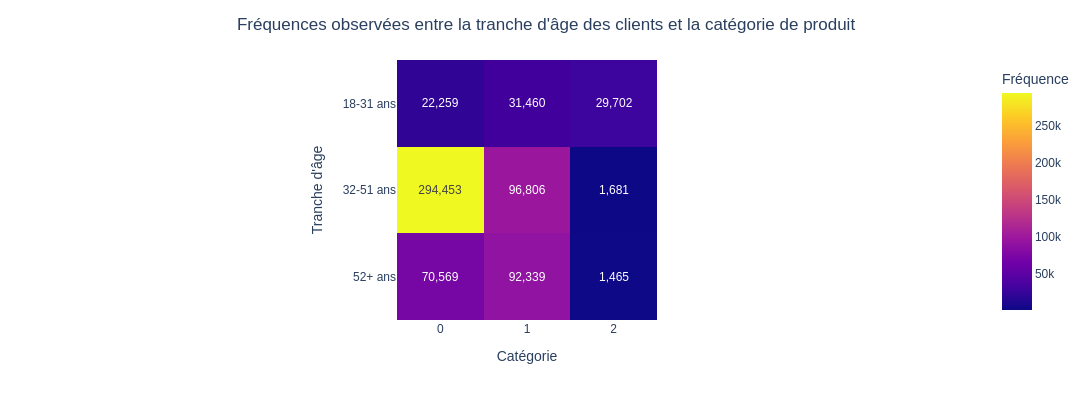

In [69]:
fig = px.imshow(contingency_table, text_auto=",d", labels={"y":"Tranche d'âge","x":"Catégorie","color":"Fréquence"}, width=650, height=400)
fig.update_layout(title="Fréquences observées entre la tranche d'âge des clients et la catégorie de produit", title_x=0.5)
fig.show()

In [70]:
contingency_table_unpivot = contingency_table.reset_index().melt(id_vars="age_group", var_name="categ", value_name="frequency")
contingency_table_unpivot

,age_group,categ,frequency
0,18-31 ans,0,22259
1,32-51 ans,0,294453
2,52+ ans,0,70569
3,18-31 ans,1,31460
4,32-51 ans,1,96806
5,52+ ans,1,92339
6,18-31 ans,2,29702
7,32-51 ans,2,1681
8,52+ ans,2,1465


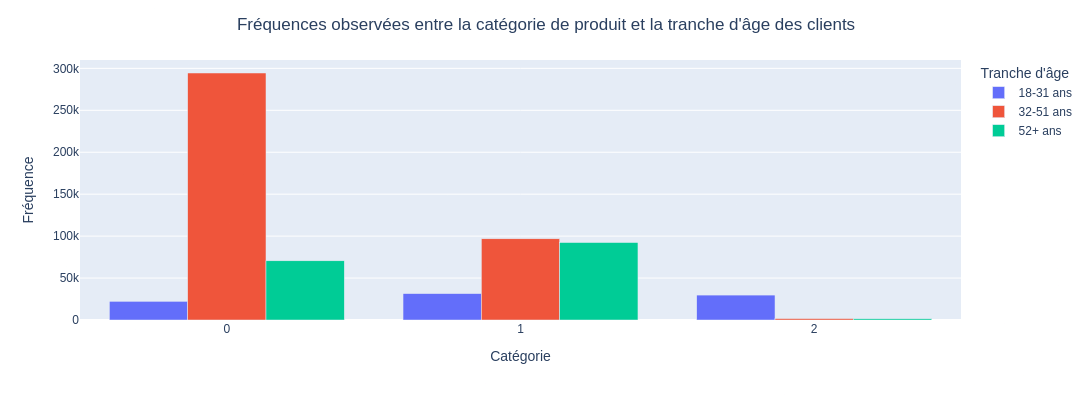

In [71]:
fig = px.bar(
    contingency_table_unpivot, x="categ", y="frequency", color="age_group", barmode="group",
    labels={"age_group":"Tranche d'âge","categ":"Catégorie","frequency":"Fréquence"},
    width=800, height=400,
)
fig.update_layout(
    title="Fréquences observées entre la catégorie de produit et la tranche d'âge des clients",
    title_x=0.5,
)
fig.show()

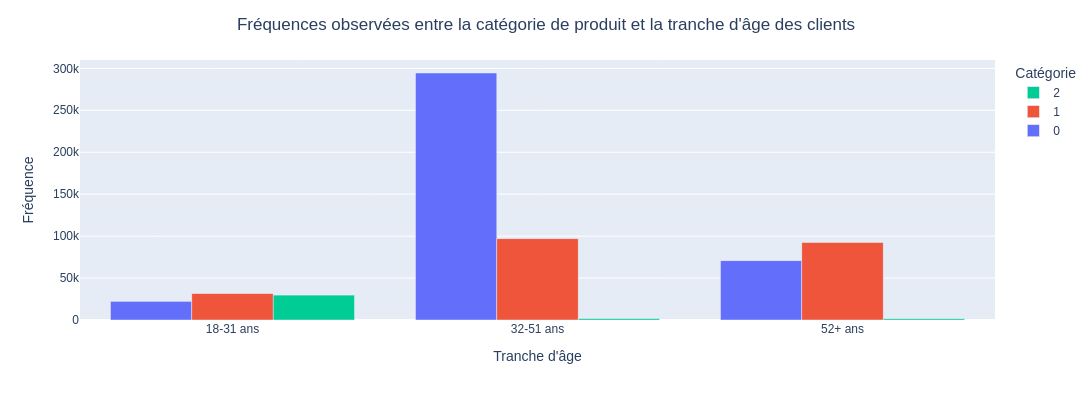

In [72]:
fig = px.bar(
    contingency_table_unpivot, x="age_group", y="frequency", color="categ", barmode="group",
    labels={"age_group":"Tranche d'âge","categ":"Catégorie","frequency":"Fréquence"},
    width=800, height=400,
)
fig.update_layout(
    title="Fréquences observées entre la catégorie de produit et la tranche d'âge des clients",
    title_x=0.5,
    legend_traceorder="reversed",
)
fig.show()

Voici ce qu'on observe.

- Les données sont qualitatives.
- Les observations sont indépendantes.
- Les échantillons sont suffisamment grands.
- Le tableau de contingence est de taille 3×3.

Le test adapté est donc le test du χ².

In [73]:
test_chi2_contingency(contingency_table)

Test du χ² entre les variables "age_group" et "categ" avec alpha = 0.050
Statistique χ² = 245339.340
p-value = 0.000
Degrés de liberté = 4
L'association entre les deux variables est significative.
V de Cramér = 0.438 : association modérée


# Autres visualisations

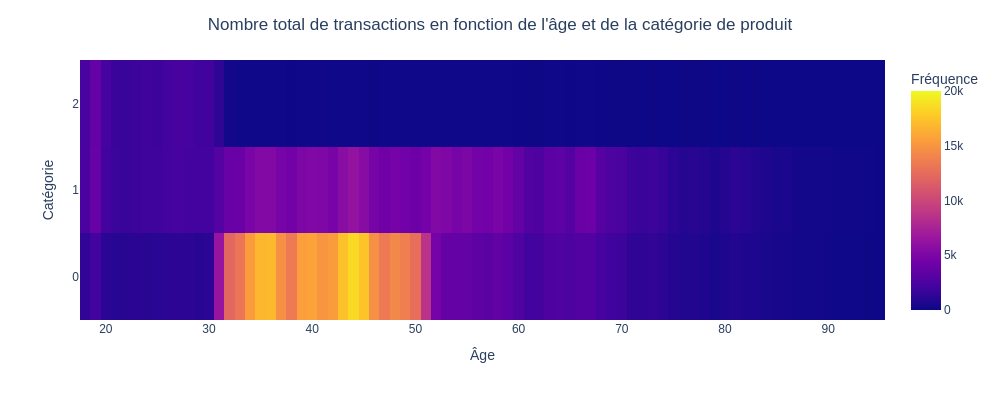

In [74]:
fig = px.density_heatmap(
    df_merge_b2c, x="age", y="categ", z="price", histfunc="count",
    labels={"age":"Âge","categ":"Catégorie"}, range_color=(0,2e4), width=1000, height=400,
)
fig.update_layout(title="Nombre total de transactions en fonction de l'âge et de la catégorie de produit", title_x=0.5)
fig.update_layout(coloraxis_colorbar_title="Fréquence")
fig.show(renderer="png")

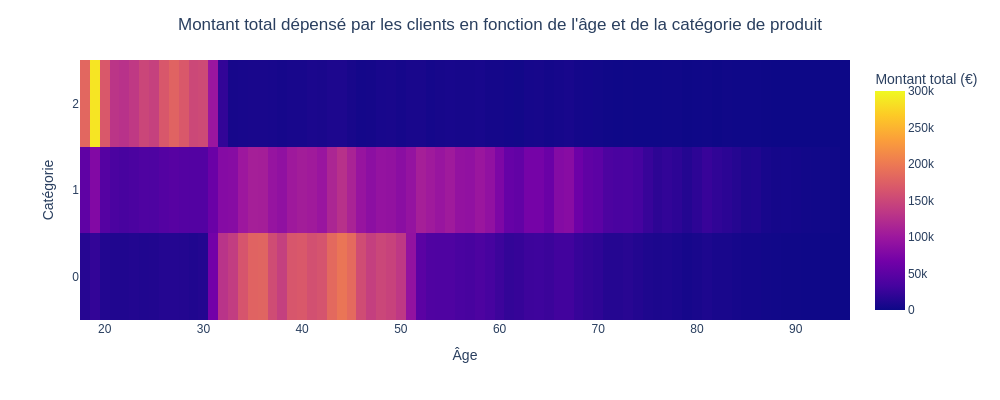

In [75]:
fig = px.density_heatmap(
    df_merge_b2c, x="age", y="categ", z="price", histfunc="sum",
    labels={"age":"Âge","categ":"Catégorie"}, range_color=(0,3e5), width=1000, height=400,
)
fig.update_layout(title="Montant total dépensé par les clients en fonction de l'âge et de la catégorie de produit", title_x=0.5)
fig.update_layout(coloraxis_colorbar_title="Montant total (€)")
fig.show(renderer="png")